# Q3: Naive Bayes Classifier for Depression Prediction

**Problem Statement:**
You have the following dataset:

| Person | Trouble Sleeping | Low Energy | Anxiety | Has Depression |
|--------|------------------|------------|---------|----------------|
| A1     | Yes              | Yes        | Yes     | Yes            |
| A2     | No               | Yes        | No      | No             |
| A3     | Yes              | No         | Yes     | Yes            |
| A4     | No               | No         | No      | No             |

A new person arrives with: **Trouble Sleeping = Yes, Low Energy = No, Anxiety = Yes**

**Question:** Predict whether the person has depression using Naive Bayes Classifier.


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Create the training dataset
data = {
    'Person': ['A1', 'A2', 'A3', 'A4'],
    'Trouble_Sleeping': ['Yes', 'No', 'Yes', 'No'],
    'Low_Energy': ['Yes', 'Yes', 'No', 'No'],
    'Anxiety': ['Yes', 'No', 'Yes', 'No'],
    'Has_Depression': ['Yes', 'No', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("=" * 60)
print("TRAINING DATASET")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)

# New person data
new_person = {
    'Trouble_Sleeping': 'Yes',
    'Low_Energy': 'No',
    'Anxiety': 'Yes'
}

print("\n" + "=" * 60)
print("NEW PERSON DATA")
print("=" * 60)
for key, value in new_person.items():
    print(f"{key.replace('_', ' ')}: {value}")
print("=" * 60)


TRAINING DATASET
Person Trouble_Sleeping Low_Energy Anxiety Has_Depression
    A1              Yes        Yes     Yes            Yes
    A2               No        Yes      No             No
    A3              Yes         No     Yes            Yes
    A4               No         No      No             No

NEW PERSON DATA
Trouble Sleeping: Yes
Low Energy: No
Anxiety: Yes


## Manual Naive Bayes Calculation

Let's calculate step by step using the Naive Bayes formula:
**P(Depression | Features) ∝ P(Depression) × P(Features | Depression)**


In [3]:
# Separate features and target
X = df[['Trouble_Sleeping', 'Low_Energy', 'Anxiety']]
y = df['Has_Depression']

# Count total instances
total_instances = len(df)

# Count instances with and without depression
depression_yes = (y == 'Yes').sum()
depression_no = (y == 'No').sum()

# Prior probabilities
P_depression_yes = depression_yes / total_instances
P_depression_no = depression_no / total_instances

print("=" * 60)
print("PRIOR PROBABILITIES")
print("=" * 60)
print(f"P(Depression = Yes) = {depression_yes}/{total_instances} = {P_depression_yes:.4f}")
print(f"P(Depression = No) = {depression_no}/{total_instances} = {P_depression_no:.4f}")
print("=" * 60)


PRIOR PROBABILITIES
P(Depression = Yes) = 2/4 = 0.5000
P(Depression = No) = 2/4 = 0.5000


In [4]:
# Calculate likelihood probabilities for each feature given depression status
# For Depression = Yes
df_yes = df[df['Has_Depression'] == 'Yes']
df_no = df[df['Has_Depression'] == 'No']

# Likelihoods for Depression = Yes
P_trouble_sleeping_yes_given_depression_yes = (df_yes['Trouble_Sleeping'] == 'Yes').sum() / len(df_yes)
P_low_energy_no_given_depression_yes = (df_yes['Low_Energy'] == 'No').sum() / len(df_yes)
P_anxiety_yes_given_depression_yes = (df_yes['Anxiety'] == 'Yes').sum() / len(df_yes)

# Likelihoods for Depression = No
P_trouble_sleeping_yes_given_depression_no = (df_no['Trouble_Sleeping'] == 'Yes').sum() / len(df_no)
P_low_energy_no_given_depression_no = (df_no['Low_Energy'] == 'No').sum() / len(df_no)
P_anxiety_yes_given_depression_no = (df_no['Anxiety'] == 'Yes').sum() / len(df_no)

print("=" * 60)
print("LIKELIHOOD PROBABILITIES")
print("=" * 60)
print("\nGiven Depression = Yes:")
print(f"  P(Trouble Sleeping = Yes | Depression = Yes) = {P_trouble_sleeping_yes_given_depression_yes:.4f}")
print(f"  P(Low Energy = No | Depression = Yes) = {P_low_energy_no_given_depression_yes:.4f}")
print(f"  P(Anxiety = Yes | Depression = Yes) = {P_anxiety_yes_given_depression_yes:.4f}")

print("\nGiven Depression = No:")
print(f"  P(Trouble Sleeping = Yes | Depression = No) = {P_trouble_sleeping_yes_given_depression_no:.4f}")
print(f"  P(Low Energy = No | Depression = No) = {P_low_energy_no_given_depression_no:.4f}")
print(f"  P(Anxiety = Yes | Depression = No) = {P_anxiety_yes_given_depression_no:.4f}")
print("=" * 60)


LIKELIHOOD PROBABILITIES

Given Depression = Yes:
  P(Trouble Sleeping = Yes | Depression = Yes) = 1.0000
  P(Low Energy = No | Depression = Yes) = 0.5000
  P(Anxiety = Yes | Depression = Yes) = 1.0000

Given Depression = No:
  P(Trouble Sleeping = Yes | Depression = No) = 0.0000
  P(Low Energy = No | Depression = No) = 0.5000
  P(Anxiety = Yes | Depression = No) = 0.0000


In [5]:
# Calculate posterior probabilities (unnormalized)
# For Depression = Yes
posterior_unnormalized_yes = (P_depression_yes * 
                              P_trouble_sleeping_yes_given_depression_yes *
                              P_low_energy_no_given_depression_yes *
                              P_anxiety_yes_given_depression_yes)

# For Depression = No
posterior_unnormalized_no = (P_depression_no * 
                             P_trouble_sleeping_yes_given_depression_no *
                             P_low_energy_no_given_depression_no *
                             P_anxiety_yes_given_depression_no)

# Normalize probabilities
normalization_factor = posterior_unnormalized_yes + posterior_unnormalized_no
posterior_yes = posterior_unnormalized_yes / normalization_factor
posterior_no = posterior_unnormalized_no / normalization_factor

print("=" * 60)
print("POSTERIOR PROBABILITY CALCULATION")
print("=" * 60)
print("\nFor Depression = Yes:")
print(f"  P(Depression = Yes) × P(Features | Depression = Yes)")
print(f"  = {P_depression_yes:.4f} × {P_trouble_sleeping_yes_given_depression_yes:.4f} × {P_low_energy_no_given_depression_yes:.4f} × {P_anxiety_yes_given_depression_yes:.4f}")
print(f"  = {posterior_unnormalized_yes:.6f}")

print("\nFor Depression = No:")
print(f"  P(Depression = No) × P(Features | Depression = No)")
print(f"  = {P_depression_no:.4f} × {P_trouble_sleeping_yes_given_depression_no:.4f} × {P_low_energy_no_given_depression_no:.4f} × {P_anxiety_yes_given_depression_no:.4f}")
print(f"  = {posterior_unnormalized_no:.6f}")

print("\n" + "-" * 60)
print("Normalized Probabilities:")
print(f"  P(Depression = Yes | Features) = {posterior_yes:.6f} ({posterior_yes*100:.2f}%)")
print(f"  P(Depression = No | Features) = {posterior_no:.6f} ({posterior_no*100:.2f}%)")
print("=" * 60)

# Prediction
prediction = 'Yes' if posterior_yes > posterior_no else 'No'
print(f"\n✅ PREDICTION: The person has depression = {prediction}")
print(f"   (Confidence: {max(posterior_yes, posterior_no)*100:.2f}%)")
print("=" * 60)


POSTERIOR PROBABILITY CALCULATION

For Depression = Yes:
  P(Depression = Yes) × P(Features | Depression = Yes)
  = 0.5000 × 1.0000 × 0.5000 × 1.0000
  = 0.250000

For Depression = No:
  P(Depression = No) × P(Features | Depression = No)
  = 0.5000 × 0.0000 × 0.5000 × 0.0000
  = 0.000000

------------------------------------------------------------
Normalized Probabilities:
  P(Depression = Yes | Features) = 1.000000 (100.00%)
  P(Depression = No | Features) = 0.000000 (0.00%)

✅ PREDICTION: The person has depression = Yes
   (Confidence: 100.00%)


## Using Scikit-learn Naive Bayes Classifier


In [6]:
# Encode categorical variables to numeric
label_encoders = {}
X_encoded = X.copy()
y_encoded = y.copy()

# Encode features
for col in X.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Train Naive Bayes classifier
nb_classifier = CategoricalNB()
nb_classifier.fit(X_encoded, y_encoded)

# Prepare new person data
new_person_encoded = []
for col in X.columns:
    le = label_encoders[col]
    new_person_encoded.append(le.transform([new_person[col]])[0])

new_person_array = np.array(new_person_encoded).reshape(1, -1)

# Make prediction
prediction_sklearn = nb_classifier.predict(new_person_array)[0]
prediction_proba = nb_classifier.predict_proba(new_person_array)[0]

# Decode prediction
prediction_label = le_target.inverse_transform([prediction_sklearn])[0]

print("=" * 60)
print("SCIKIT-LEARN NAIVE BAYES CLASSIFIER")
print("=" * 60)
print(f"Prediction: {prediction_label}")
print(f"\nPrediction Probabilities:")
print(f"  P(Depression = No): {prediction_proba[0]:.6f} ({prediction_proba[0]*100:.2f}%)")
print(f"  P(Depression = Yes): {prediction_proba[1]:.6f} ({prediction_proba[1]*100:.2f}%)")
print("=" * 60)


SCIKIT-LEARN NAIVE BAYES CLASSIFIER
Prediction: Yes

Prediction Probabilities:
  P(Depression = No): 0.100000 (10.00%)
  P(Depression = Yes): 0.900000 (90.00%)


/Users/shivamkumar/Desktop/shivam/ism_assignment/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/Users/shivamkumar/Desktop/shivam/ism_assignment/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


## Visualization


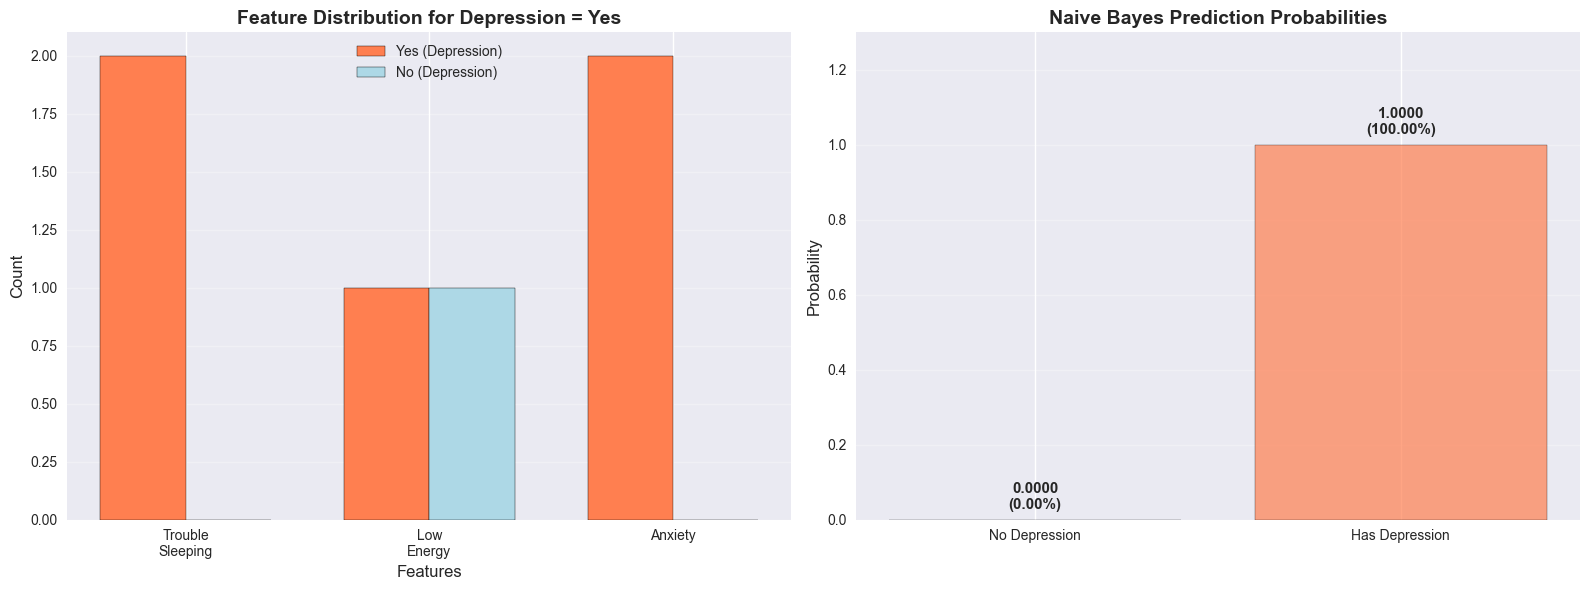


SUMMARY TABLE:
         Feature Value  P(Feature | Depression=Yes)  P(Feature | Depression=No)
Trouble Sleeping   Yes                          1.0                         0.0
      Low Energy    No                          0.5                         0.5
         Anxiety   Yes                          1.0                         0.0


In [7]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature distribution
feature_names = ['Trouble\nSleeping', 'Low\nEnergy', 'Anxiety']
yes_counts = [df[df['Has_Depression'] == 'Yes'][feat].value_counts().get('Yes', 0) 
              for feat in ['Trouble_Sleeping', 'Low_Energy', 'Anxiety']]
no_counts = [df[df['Has_Depression'] == 'Yes'][feat].value_counts().get('No', 0) 
             for feat in ['Trouble_Sleeping', 'Low_Energy', 'Anxiety']]

x = np.arange(len(feature_names))
width = 0.35

axes[0].bar(x - width/2, yes_counts, width, label='Yes (Depression)', color='coral', edgecolor='black')
axes[0].bar(x + width/2, no_counts, width, label='No (Depression)', color='lightblue', edgecolor='black')
axes[0].set_xlabel('Features', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Feature Distribution for Depression = Yes', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Prediction probabilities
categories = ['No Depression', 'Has Depression']
probabilities = [posterior_no, posterior_yes]
colors = ['lightgreen', 'coral']

bars = axes[1].bar(categories, probabilities, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Naive Bayes Prediction Probabilities', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(probabilities) * 1.3)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{prob:.4f}\n({prob*100:.2f}%)', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Summary table
summary_data = {
    'Feature': ['Trouble Sleeping', 'Low Energy', 'Anxiety'],
    'Value': ['Yes', 'No', 'Yes'],
    'P(Feature | Depression=Yes)': [
        P_trouble_sleeping_yes_given_depression_yes,
        P_low_energy_no_given_depression_yes,
        P_anxiety_yes_given_depression_yes
    ],
    'P(Feature | Depression=No)': [
        P_trouble_sleeping_yes_given_depression_no,
        P_low_energy_no_given_depression_no,
        P_anxiety_yes_given_depression_no
    ]
}
summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE:")
print(summary_df.to_string(index=False))
